In [3]:
import sys
print(sys.executable)

c:\Users\DELL\Desktop\Bank_Loan_Default_Prediction\venv\Scripts\python.exe


In [4]:
import pandas as pd
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
df = pd.read_csv("../data/raw/Loan_default.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (255347, 18)


In [6]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 255347
Columns: 18


In [8]:
df.columns.tolist()

['LoanID',
 'Age',
 'Income',
 'LoanAmount',
 'CreditScore',
 'MonthsEmployed',
 'NumCreditLines',
 'InterestRate',
 'LoanTerm',
 'DTIRatio',
 'Education',
 'EmploymentType',
 'MaritalStatus',
 'HasMortgage',
 'HasDependents',
 'LoanPurpose',
 'HasCoSigner',
 'Default']

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  Default         25534

In [10]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [13]:
df.describe(include="object")

C:\Users\DELL\AppData\Local\Temp\ipykernel_12752\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,LoanID,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
count,255347,255347,255347,255347,255347,255347,255347,255347
unique,255347,4,4,3,2,2,5,2
top,I38PQUQS96,Bachelor's,Part-time,Married,Yes,Yes,Business,Yes
freq,1,64366,64161,85302,127677,127742,51298,127701


In [14]:
df["Default"].value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

In [15]:
df["Default"].value_counts(normalize=True) * 100

Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64

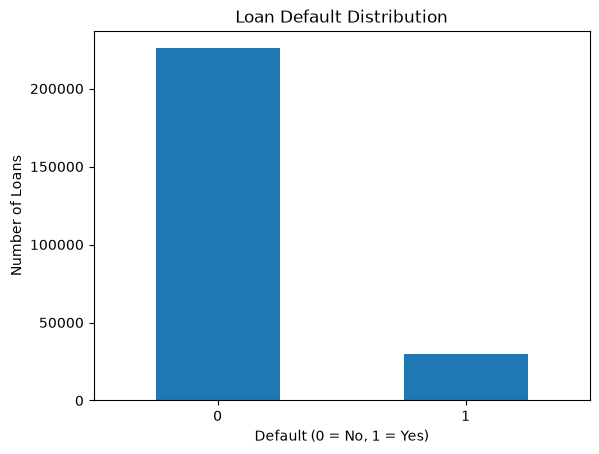

In [16]:
import matplotlib.pyplot as plt

df["Default"].value_counts().plot(kind="bar")

plt.title("Loan Default Distribution")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Number of Loans")
plt.xticks(rotation=0)
plt.show()

In [17]:
age_default = df.groupby("Age")["Default"].mean() * 100

age_default.head()

Age
18    22.194922
19    22.083417
20    22.341082
21    20.290448
22    22.132797
Name: Default, dtype: float64

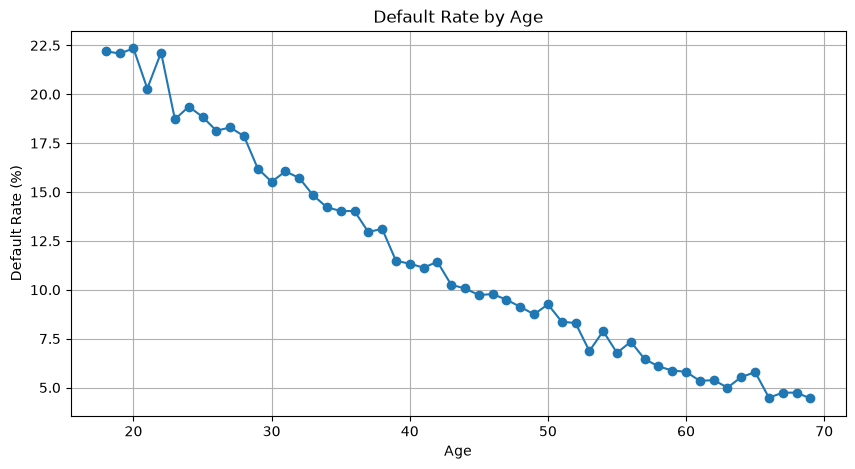

In [18]:
plt.figure(figsize=(10, 5))

age_default.plot(kind="line", marker="o")

plt.title("Default Rate by Age")
plt.xlabel("Age")
plt.ylabel("Default Rate (%)")
plt.grid(True)
plt.show()

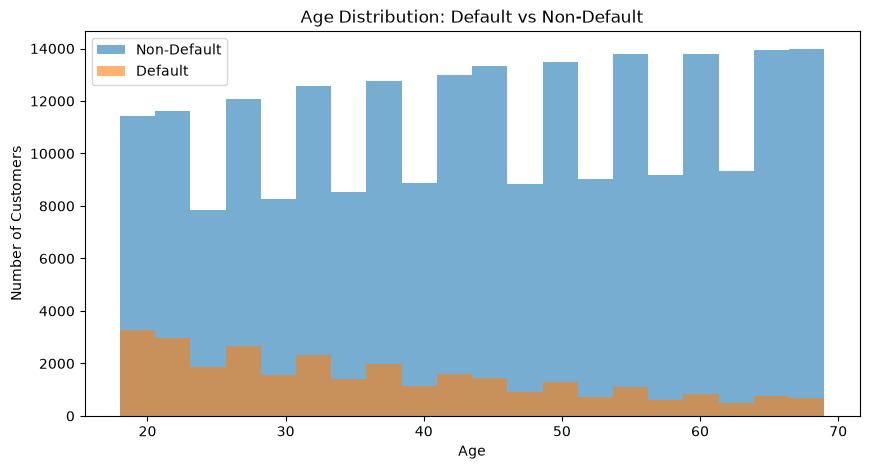

In [19]:
plt.figure(figsize=(10, 5))

df[df["Default"] == 0]["Age"].plot(
    kind="hist",
    bins=20,
    alpha=0.6,
    label="Non-Default"
)

df[df["Default"] == 1]["Age"].plot(
    kind="hist",
    bins=20,
    alpha=0.6,
    label="Default"
)

plt.title("Age Distribution: Default vs Non-Default")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.legend()
plt.show()

In [20]:
df["IncomeGroup"] = pd.qcut(
    df["Income"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

income_default = df.groupby("IncomeGroup", observed=True)["Default"].mean() * 100

income_default

IncomeGroup
Very Low     18.538534
Low          11.380904
Medium        9.863319
High          9.306834
Very High     8.974133
Name: Default, dtype: float64

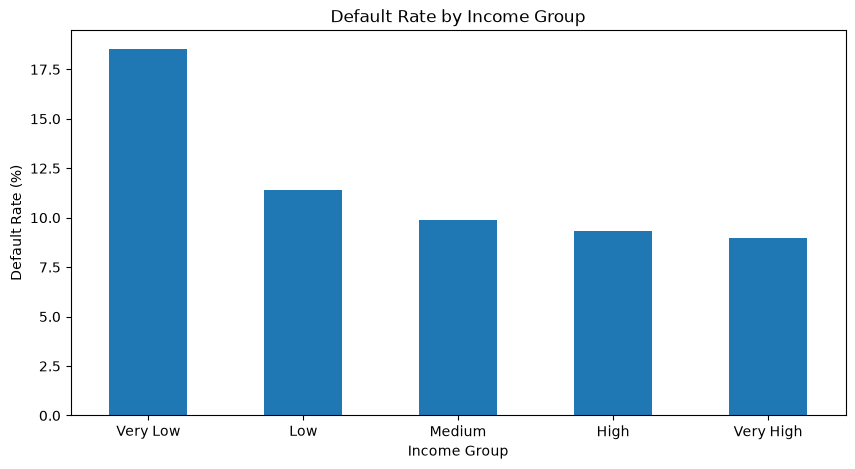

In [21]:
plt.figure(figsize=(10, 5))

income_default.plot(kind="bar")

plt.title("Default Rate by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.show()

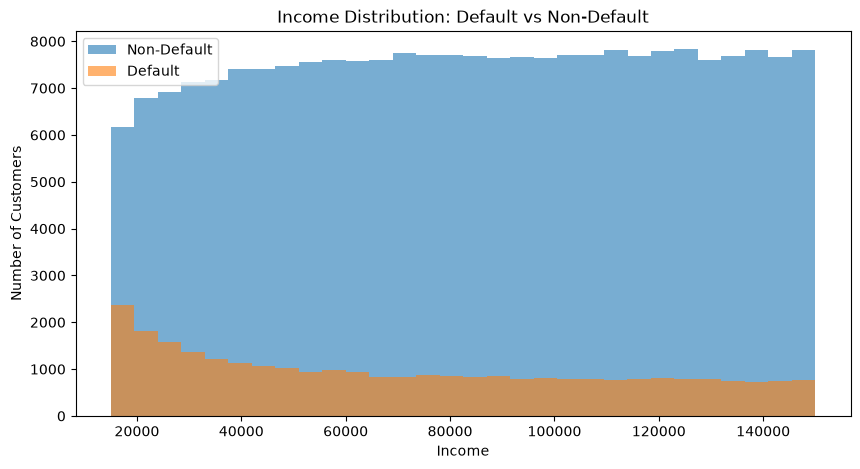

In [22]:
plt.figure(figsize=(10, 5))

df[df["Default"] == 0]["Income"].plot(
    kind="hist",
    bins=30,
    alpha=0.6,
    label="Non-Default"
)

df[df["Default"] == 1]["Income"].plot(
    kind="hist",
    bins=30,
    alpha=0.6,
    label="Default"
)

plt.title("Income Distribution: Default vs Non-Default")
plt.xlabel("Income")
plt.ylabel("Number of Customers")
plt.legend()
plt.show()

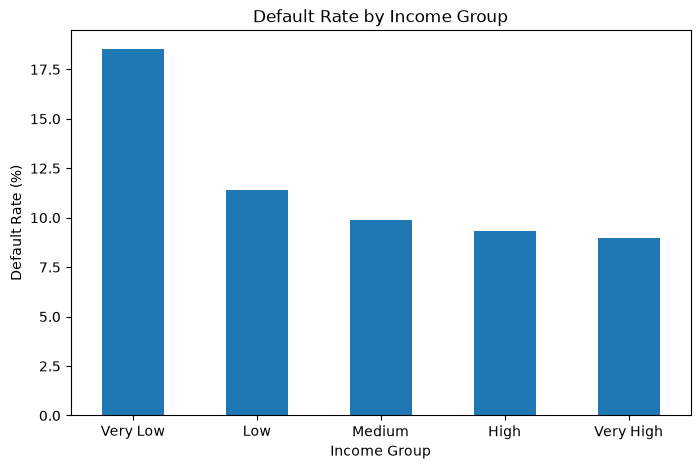

In [23]:
plt.figure(figsize=(8, 5))

income_default.plot(kind="bar")

plt.title("Default Rate by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [24]:
df["LoanAmountGroup"] = pd.qcut(
    df["LoanAmount"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

loan_amount_default = (
    df.groupby("LoanAmountGroup", observed=True)["Default"].mean() * 100
)

loan_amount_default

LoanAmountGroup
Very Low      8.049736
Low           9.665355
Medium       11.196616
High         13.336597
Very High    15.815857
Name: Default, dtype: float64

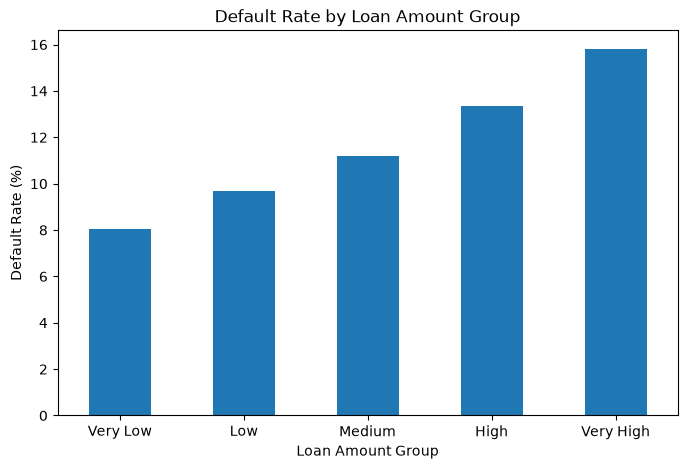

In [25]:
plt.figure(figsize=(8, 5))

loan_amount_default.plot(kind="bar")

plt.title("Default Rate by Loan Amount Group")
plt.xlabel("Loan Amount Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [26]:
df["CreditScoreGroup"] = pd.qcut(
    df["CreditScore"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

credit_default = (
    df.groupby("CreditScoreGroup", observed=True)["Default"].mean() * 100
)

credit_default

CreditScoreGroup
Very Low     13.207033
Low          12.227783
Medium       11.597529
High         10.846157
Very High    10.167221
Name: Default, dtype: float64

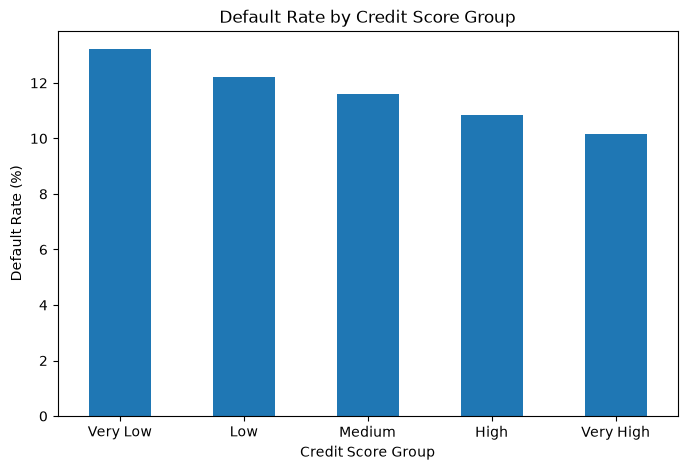

In [27]:
plt.figure(figsize=(8, 5))

credit_default.plot(kind="bar")

plt.title("Default Rate by Credit Score Group")
plt.xlabel("Credit Score Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [28]:
df["InterestRateGroup"] = pd.qcut(
    df["InterestRate"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

interest_default = (
    df.groupby("InterestRateGroup", observed=True)["Default"].mean() * 100
)

interest_default

InterestRateGroup
Very Low      6.311221
Low           8.431660
Medium       11.069720
High         14.228120
Very High    18.040984
Name: Default, dtype: float64

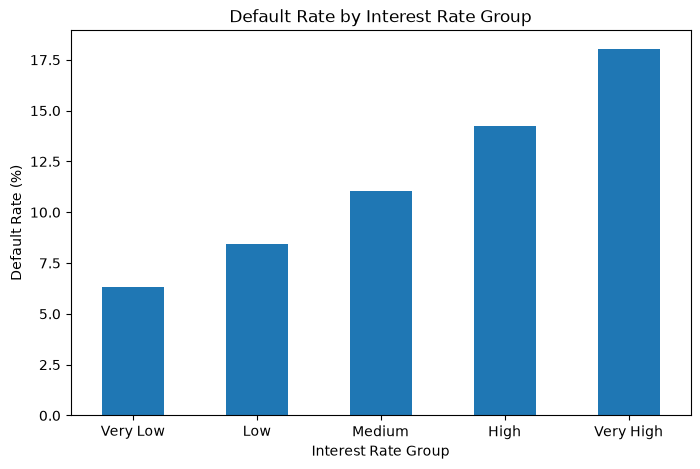

In [29]:
plt.figure(figsize=(8, 5))

interest_default.plot(kind="bar")

plt.title("Default Rate by Interest Rate Group")
plt.xlabel("Interest Rate Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [30]:
categorical_cols = [
    "Education",
    "EmploymentType",
    "MaritalStatus",
    "LoanPurpose"
]

for col in categorical_cols:
    print("\n", col)
    print(
        (df.groupby(col)["Default"].mean() * 100)
        .round(2)
        .sort_values(ascending=False)
    )


 Education
Education
High School    12.88
Bachelor's     12.10
Master's       10.87
PhD            10.59
Name: Default, dtype: float64

 EmploymentType
EmploymentType
Unemployed       13.55
Part-time        11.97
Self-employed    11.46
Full-time         9.46
Name: Default, dtype: float64

 MaritalStatus
MaritalStatus
Divorced    12.53
Single      11.91
Married     10.40
Name: Default, dtype: float64

 LoanPurpose
LoanPurpose
Business     12.33
Auto         11.88
Education    11.84
Other        11.79
Home         10.23
Name: Default, dtype: float64


In [31]:
numeric_cols = [
    "Age",
    "Income",
    "LoanAmount",
    "CreditScore",
    "MonthsEmployed",
    "NumCreditLines",
    "InterestRate",
    "LoanTerm",
    "DTIRatio",
    "Default"
]

correlation = df[numeric_cols].corr()

correlation["Default"].sort_values(ascending=False)

Default           1.000000
InterestRate      0.131273
LoanAmount        0.086659
NumCreditLines    0.028330
DTIRatio          0.019236
LoanTerm          0.000545
CreditScore      -0.034166
MonthsEmployed   -0.097374
Income           -0.099119
Age              -0.167783
Name: Default, dtype: float64

In [32]:
eda_columns = [
    "IncomeGroup",
    "LoanAmountGroup",
    "CreditScoreGroup",
    "InterestRateGroup",
    "DTIGroup"
]

df = df.drop(columns=eda_columns, errors="ignore")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (255347, 18)
Columns: ['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']


In [33]:
# Remove unique LoanID
df_model = df.drop(columns=["LoanID"])

# Separate features and target
X = df_model.drop(columns=["Default"])
y = df_model["Default"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (255347, 16)
Target shape: (255347,)


In [34]:
X_encoded = pd.get_dummies(
    X,
    columns=[
        "Education",
        "EmploymentType",
        "MaritalStatus",
        "HasMortgage",
        "HasDependents",
        "LoanPurpose",
        "HasCoSigner"
    ],
    drop_first=True,
    dtype=int
)

print("Encoded features shape:", X_encoded.shape)
print(X_encoded.head())

Encoded features shape: (255347, 24)
   Age  Income  LoanAmount  CreditScore  MonthsEmployed  NumCreditLines  \
0   56   85994       50587          520              80               4   
1   69   50432      124440          458              15               1   
2   46   84208      129188          451              26               3   
3   32   31713       44799          743               0               3   
4   60   20437        9139          633               8               4   

   InterestRate  LoanTerm  DTIRatio  Education_High School  ...  \
0         15.23        36      0.44                      0  ...   
1          4.81        60      0.68                      0  ...   
2         21.17        24      0.31                      0  ...   
3          7.07        24      0.23                      1  ...   
4          6.51        48      0.73                      0  ...   

   EmploymentType_Unemployed  MaritalStatus_Married  MaritalStatus_Single  \
0                          0    

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (204277, 24)
Testing features: (51070, 24)
Training target: (204277,)
Testing target: (51070,)


In [36]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


c:\Users\DELL\Desktop\Bank_Loan_Default_Prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [37]:
y_pred = logistic_model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

y_prob = logistic_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.8848
Precision: 0.5674
Recall   : 0.0341
F1 Score : 0.0643
ROC-AUC  : 0.7472

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.57      0.03      0.06      5931

    accuracy                           0.88     51070
   macro avg       0.73      0.52      0.50     51070
weighted avg       0.85      0.88      0.84     51070



[[44985   154]
 [ 5729   202]]


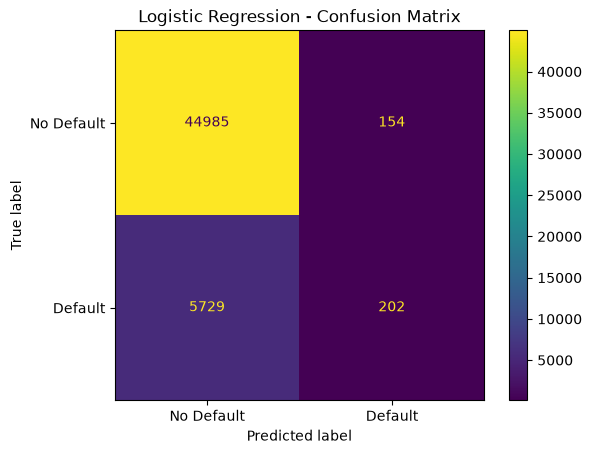

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Default", "Default"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [40]:
balanced_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

balanced_model.fit(X_train, y_train)

y_pred_balanced = balanced_model.predict(X_test)

print("Balanced Logistic Regression trained successfully!")

Balanced Logistic Regression trained successfully!


c:\Users\DELL\Desktop\Bank_Loan_Default_Prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [42]:
balanced_scaled_model = LogisticRegression(
    max_iter=2000,
    random_state=42,
    class_weight="balanced"
)

balanced_scaled_model.fit(X_train_scaled, y_train)

y_pred_balanced = balanced_scaled_model.predict(X_test_scaled)

print("Balanced scaled Logistic Regression trained successfully!")

Balanced scaled Logistic Regression trained successfully!


In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_bal = accuracy_score(y_test, y_pred_balanced)
precision_bal = precision_score(y_test, y_pred_balanced)
recall_bal = recall_score(y_test, y_pred_balanced)
f1_bal = f1_score(y_test, y_pred_balanced)

y_prob_bal = balanced_scaled_model.predict_proba(X_test_scaled)[:, 1]
roc_auc_bal = roc_auc_score(y_test, y_prob_bal)

print("Accuracy :", round(accuracy_bal, 4))
print("Precision:", round(precision_bal, 4))
print("Recall   :", round(recall_bal, 4))
print("F1 Score :", round(f1_bal, 4))
print("ROC-AUC  :", round(roc_auc_bal, 4))

Accuracy : 0.6765
Precision: 0.2196
Recall   : 0.6994
F1 Score : 0.3343
ROC-AUC  : 0.7532


In [44]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1 Score :", round(f1_rf, 4))
print("ROC-AUC  :", round(roc_auc_rf, 4))

Accuracy : 0.8808
Precision: 0.4588
Recall   : 0.1482
F1 Score : 0.224
ROC-AUC  : 0.7473


In [46]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [47]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("Accuracy :", round(accuracy_xgb, 4))
print("Precision:", round(precision_xgb, 4))
print("Recall   :", round(recall_xgb, 4))
print("F1 Score :", round(f1_xgb, 4))
print("ROC-AUC  :", round(roc_auc_xgb, 4))

Accuracy : 0.8862
Precision: 0.5781
Recall   : 0.073
F1 Score : 0.1296
ROC-AUC  : 0.7546


In [48]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

xgb_balanced = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_balanced.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

y_pred_xgb_balanced = xgb_balanced.predict(X_test)

print("Balanced XGBoost trained successfully!")

Balanced XGBoost trained successfully!


In [49]:
accuracy_xgb_bal = accuracy_score(y_test, y_pred_xgb_balanced)
precision_xgb_bal = precision_score(y_test, y_pred_xgb_balanced)
recall_xgb_bal = recall_score(y_test, y_pred_xgb_balanced)
f1_xgb_bal = f1_score(y_test, y_pred_xgb_balanced)

y_prob_xgb_bal = xgb_balanced.predict_proba(X_test)[:, 1]
roc_auc_xgb_bal = roc_auc_score(y_test, y_prob_xgb_bal)

print("Accuracy :", round(accuracy_xgb_bal, 4))
print("Precision:", round(precision_xgb_bal, 4))
print("Recall   :", round(recall_xgb_bal, 4))
print("F1 Score :", round(f1_xgb_bal, 4))
print("ROC-AUC  :", round(roc_auc_xgb_bal, 4))

Accuracy : 0.7117
Precision: 0.2348
Recall   : 0.6562
F1 Score : 0.3459
ROC-AUC  : 0.7532


In [50]:
y_prob_xgb_bal[:10]

array([0.22034536, 0.06920736, 0.23741183, 0.49018875, 0.3351806 ,
       0.0367346 , 0.7263435 , 0.20509723, 0.71486795, 0.56833565],
      dtype=float32)

In [51]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    y_pred_threshold = (y_prob_xgb_bal >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"Threshold: {threshold} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

Threshold: 0.3 | Precision: 0.1628 | Recall: 0.8791 | F1: 0.2747
Threshold: 0.4 | Precision: 0.1953 | Recall: 0.7830 | F1: 0.3127
Threshold: 0.5 | Precision: 0.2348 | Recall: 0.6562 | F1: 0.3459
Threshold: 0.6 | Precision: 0.2879 | Recall: 0.5115 | F1: 0.3685
Threshold: 0.7 | Precision: 0.3594 | Recall: 0.3414 | F1: 0.3502


In [52]:
best_threshold = 0.6

y_pred_final = (y_prob_xgb_bal >= best_threshold).astype(int)

print("Final predictions created!")

Final predictions created!


[[37636  7503]
 [ 2897  3034]]


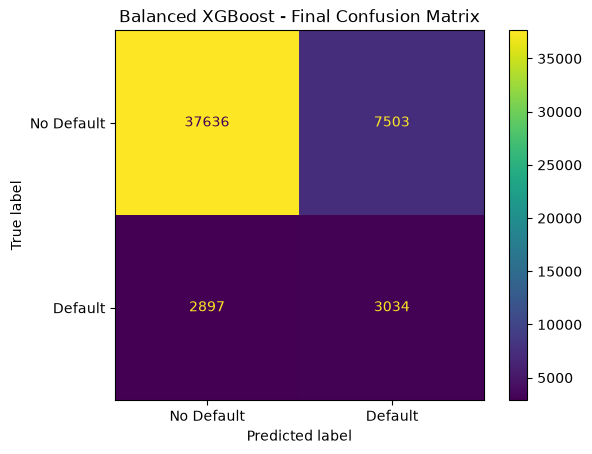

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_final = confusion_matrix(y_test, y_pred_final)

print(cm_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["No Default", "Default"]
)

disp.plot()
plt.title("Balanced XGBoost - Final Confusion Matrix")
plt.show()

In [54]:
final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)

print("Final Model Performance")
print("-----------------------")
print("Accuracy :", round(final_accuracy, 4))
print("Precision:", round(final_precision, 4))
print("Recall   :", round(final_recall, 4))
print("F1 Score :", round(final_f1, 4))
print("ROC-AUC  :", round(roc_auc_xgb_bal, 4))

Final Model Performance
-----------------------
Accuracy : 0.7964
Precision: 0.2879
Recall   : 0.5115
F1 Score : 0.3685
ROC-AUC  : 0.7532


In [55]:
import os

os.makedirs("../data/cleaned", exist_ok=True)

df.to_csv(
    "../data/cleaned/loan_default_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [56]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    xgb_balanced,
    "../models/balanced_xgboost_model.pkl"
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [57]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_balanced.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

                      Feature  Importance
0                         Age    0.122950
6                InterestRate    0.073542
1                      Income    0.062463
23            HasCoSigner_Yes    0.059525
18          HasDependents_Yes    0.054406
4              MonthsEmployed    0.051712
14  EmploymentType_Unemployed    0.048972
2                  LoanAmount    0.047457
17            HasMortgage_Yes    0.038290
15      MaritalStatus_Married    0.037339


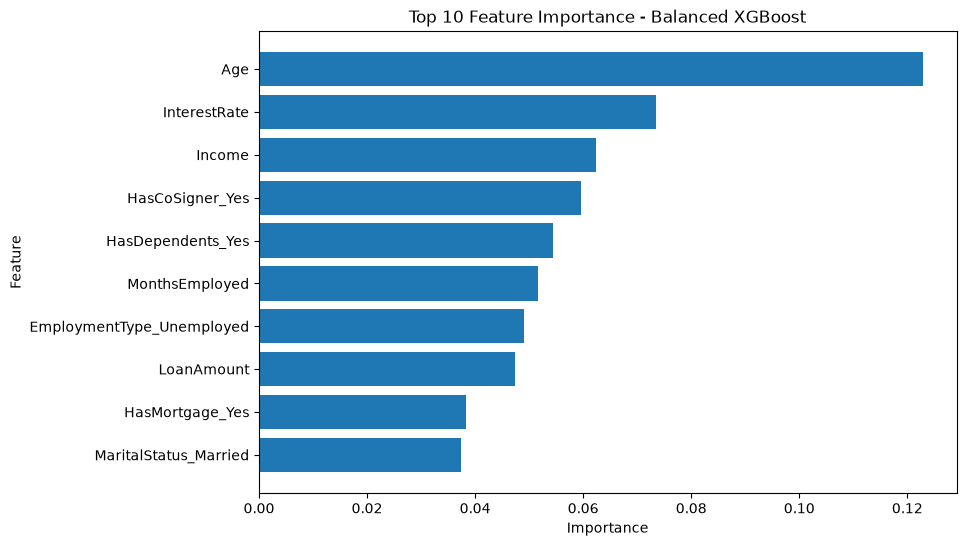

In [58]:
top_features = feature_importance.head(10).sort_values(
    by="Importance"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Feature Importance - Balanced XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [59]:
model_results = pd.DataFrame({
    "Model": [
        "Balanced Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Balanced XGBoost"
    ],
    "Accuracy": [
        accuracy_bal,
        accuracy_rf,
        accuracy_xgb,
        accuracy_xgb_bal
    ],
    "Recall": [
        recall_bal,
        recall_rf,
        recall_xgb,
        recall_xgb_bal
    ],
    "F1 Score": [
        f1_bal,
        f1_rf,
        f1_xgb,
        f1_xgb_bal
    ],
    "ROC-AUC": [
        roc_auc_bal,
        roc_auc_rf,
        roc_auc_xgb,
        roc_auc_xgb_bal
    ]
})

model_results

,Model,Accuracy,Recall,F1 Score,ROC-AUC
0,Balanced Logistic Regression,0.676503,0.699376,0.334287,0.753179
1,Random Forest,0.880771,0.148204,0.224035,0.747260
2,XGBoost,0.886156,0.073006,0.129641,0.754623
3,Balanced XGBoost,0.711729,0.656213,0.345863,0.753163


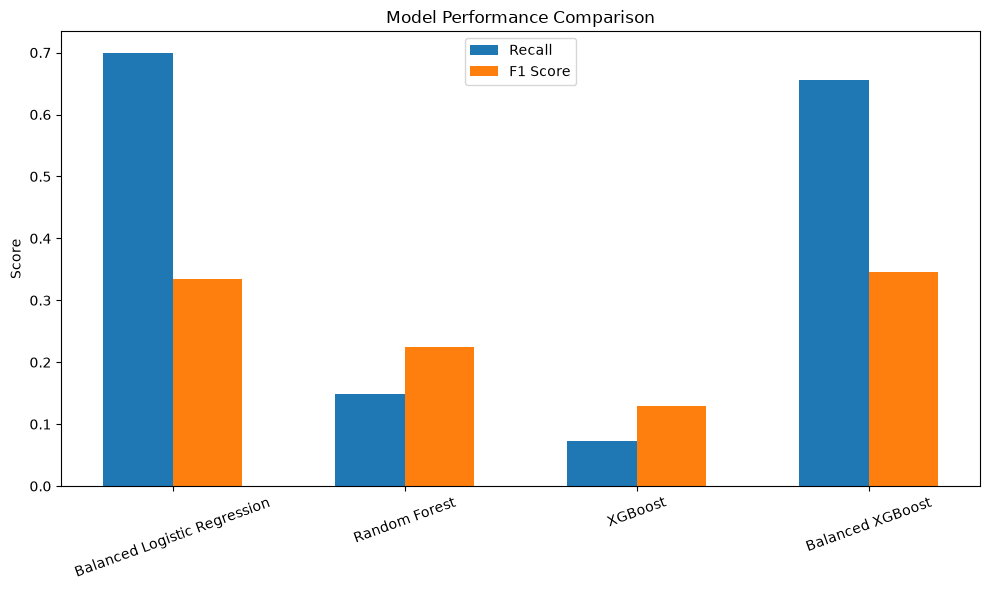

In [60]:
plt.figure(figsize=(10, 6))

x = range(len(model_results))

plt.bar(
    [i - 0.15 for i in x],
    model_results["Recall"],
    width=0.3,
    label="Recall"
)

plt.bar(
    [i + 0.15 for i in x],
    model_results["F1 Score"],
    width=0.3,
    label="F1 Score"
)

plt.xticks(x, model_results["Model"], rotation=20)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [61]:
import joblib

final_model_info = {
    "model": xgb_balanced,
    "threshold": 0.6
}

joblib.dump(
    final_model_info,
    "../models/final_loan_default_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!
